# D · EDA — 신호가 어디에 있는가

**목적**: 모델을 더 돌리기 전에 *신호의 위치와 크기*를 먼저 확인한다.
앞선 A/B/C에서 성능이 baseline을 거의 못 넘었기 때문에, **과제의 난이도 자체**를 진단한다.

**핵심 질문**
1. CSW는 무엇에 따라 변하는가? (카운트·이닝·좌우·투수)
2. 투구 전 정보로 도달 가능한 **천장**은 어디인가?
3. 원래 목표인 **CSW%(비율) 예측**에서는 쓸 만한가?

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V3 = Path("out/v3")
meta = json.load(open("cache/meta.json")); df = pd.read_parquet("cache/features.parquet")
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy(); te = df["game_year"].eq(2019).to_numpy()
BASE = {"league_mean": 0.5957, "count_only": 0.5790}
print(f"train {int(tr.sum()):,} / test {int(te.sum()):,} | 피처 basic {len(meta['basic_feats'])} "
      f"/ derived {len(meta['derived_feats'])} / +PitchPredict {len(meta['pp_feats'])} = full {len(meta['full_feats'])}")

train 238,054 / test 94,150 | 피처 basic 36 / derived 205 / +PitchPredict 52 = full 257


## 1. 타깃 분해 — CSW는 두 개의 다른 사건이다
`CSW = 콜드스트라이크(지켜봄) + 헛스윙(휘두름)`. 두 경로의 결정요인이 다르다 → F에서 분리 모델링의 근거.

CSW 0.282 = called 0.170 + whiff 0.112
스윙률 0.471 | 스윙 중 헛스윙 0.237 | 지켜본 중 콜스트라이크 0.322


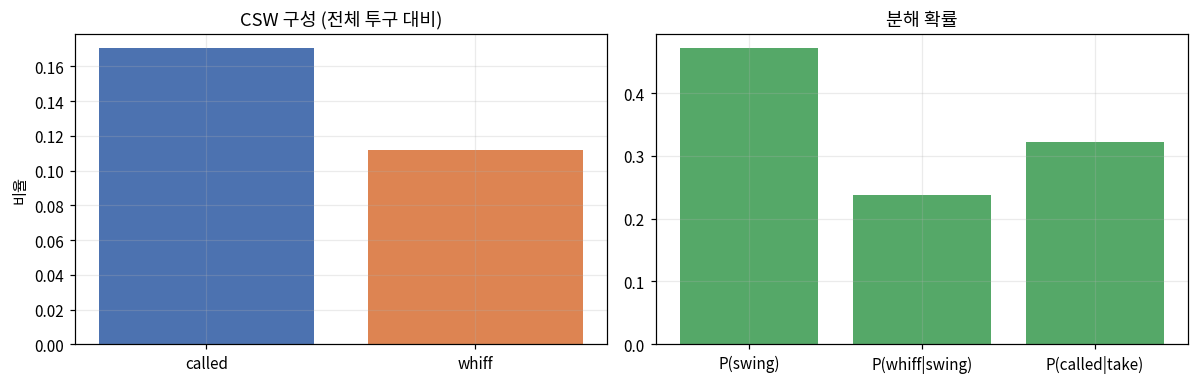

In [2]:
E = json.load(open(V3/"eda.json")); comp = E["components"]
print(f"CSW {comp['csw']:.3f} = called {comp['called']:.3f} + whiff {comp['whiff']:.3f}")
print(f"스윙률 {comp['swing']:.3f} | 스윙 중 헛스윙 {comp['whiff_given_swing']:.3f} | 지켜본 중 콜스트라이크 {comp['called_given_take']:.3f}")
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
ax[0].bar(["called","whiff"], [comp["called"], comp["whiff"]], color=["#4C72B0","#DD8452"])
ax[0].set_title("CSW 구성 (전체 투구 대비)"); ax[0].set_ylabel("비율")
ax[1].bar(["P(swing)","P(whiff|swing)","P(called|take)"],
          [comp["swing"], comp["whiff_given_swing"], comp["called_given_take"]], color="#55A868")
ax[1].set_title("분해 확률"); plt.tight_layout(); plt.show()

## 2. 카운트가 가장 강한 신호
2스트라이크에서 CSW가 급락(타자가 커트/보호 스윙) — 카운트만으로도 상당한 설명력.

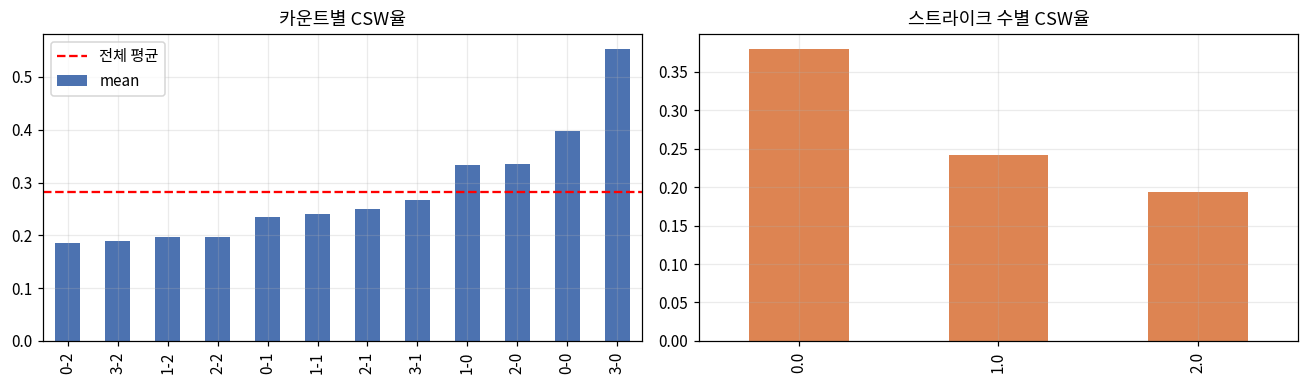

최저 0-2 0.186 | 최고 3-0 0.553


In [3]:
bc = pd.DataFrame(E["by_count"]).T.sort_values("mean")
fig, ax = plt.subplots(1,2, figsize=(12,3.6))
bc["mean"].plot.bar(ax=ax[0], color="#4C72B0"); ax[0].axhline(comp["csw"], ls="--", c="r", label="전체 평균")
ax[0].set_title("카운트별 CSW율"); ax[0].legend()
pd.Series(E["by_strikes"]).plot.bar(ax=ax[1], color="#DD8452"); ax[1].set_title("스트라이크 수별 CSW율")
plt.tight_layout(); plt.show()
print("최저", bc.index[0], round(bc['mean'].iloc[0],3), "| 최고", bc.index[-1], round(bc['mean'].iloc[-1],3))

## 3. 투수 간 차이 vs 상황 차이

투수별 CSW율: 최저 0.234 ~ 최고 0.339 (SD 0.0247, n=40)


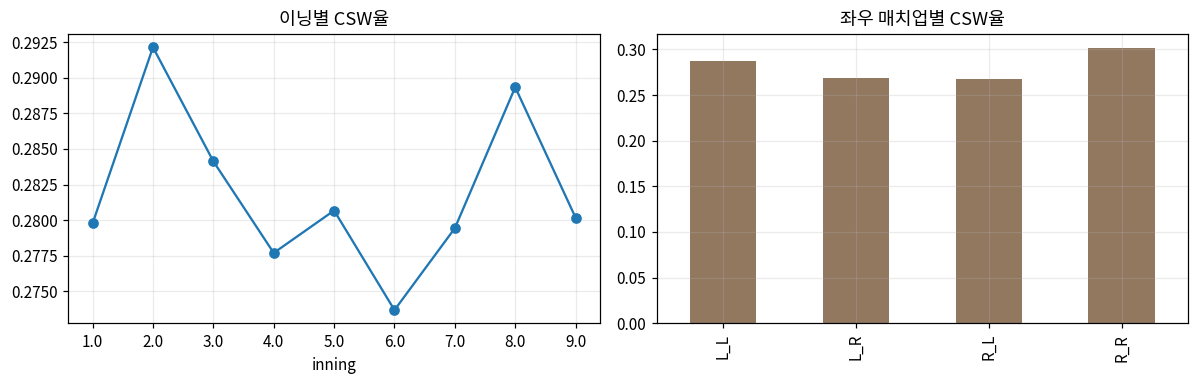

In [4]:
ps = E["pitcher_spread"]
print(f"투수별 CSW율: 최저 {ps['min']:.3f} ~ 최고 {ps['max']:.3f} (SD {ps['sd']:.4f}, n={ps['n']})")
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
pd.Series(E["by_inning"]).plot(marker="o", ax=ax[0]); ax[0].set_title("이닝별 CSW율"); ax[0].set_xlabel("inning")
pd.Series(E["by_matchup"]).plot.bar(ax=ax[1], color="#937860"); ax[1].set_title("좌우 매치업별 CSW율")
plt.tight_layout(); plt.show()

## 4. ★ 천장 진단 — 신호의 90%는 '그 공이 어디로 갔는가'에 있다
투구 전 정보만으로는 알 수 없는 **현재 투구의 위치·구위**를 넣어보면 성능이 어떻게 변하는지 비교한다.
(`diagnose_ceiling.py` 결과)

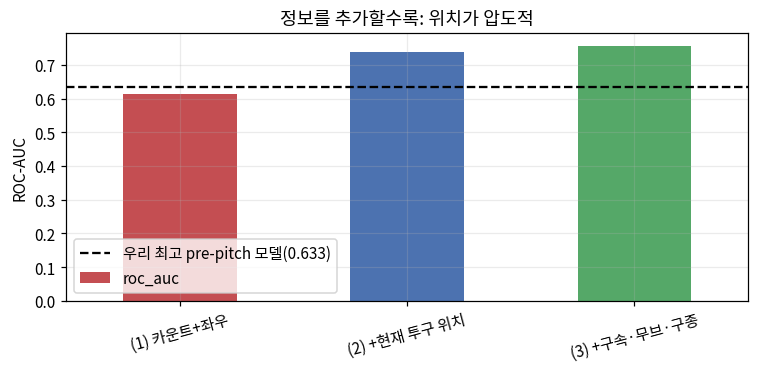

위치 추가 효과: AUC +0.125 | 우리 205~342개 투구전 피처 전부: AUC +0.020


,logloss,roc_auc,pr_auc
(1) 카운트+좌우,0.5794,0.6132,0.3675
(2) +현재 투구 위치,0.5487,0.7386,0.5218
(3) +구속·무브·구종,0.5234,0.7564,0.5466


In [5]:
C = json.load(open(V3.parent/"v2"/"ceiling_diagnosis.json"))
rows = {"(1) 카운트+좌우": C["1_context_only"], "(2) +현재 투구 위치": C["2_plus_location"],
        "(3) +구속·무브·구종": C["3_plus_stuff"]}
t = pd.DataFrame(rows).T[["logloss","roc_auc","pr_auc"]]
fig, ax = plt.subplots(figsize=(7,3.5))
t["roc_auc"].plot.bar(ax=ax, color=["#C44E52","#4C72B0","#55A868"])
ax.axhline(0.6332, ls="--", c="k", label="우리 최고 pre-pitch 모델(0.633)")
ax.set_ylabel("ROC-AUC"); ax.set_title("정보를 추가할수록: 위치가 압도적"); ax.legend(); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()
print("위치 추가 효과: AUC +%.3f | 우리 205~342개 투구전 피처 전부: AUC +%.3f"
      % (C["2_plus_location"]["roc_auc"]-C["1_context_only"]["roc_auc"], 0.6332-C["1_context_only"]["roc_auc"]))
t

## 5. ★ 비율(CSW%) 예측에서는? — 단순 이동평균에 진다
원래 목표는 투수의 **CSW%** 예측이었다. 투구 단위 확률을 경기 단위로 평균내 비교.

등판 997개 | 실제 CSW% SD 0.0556


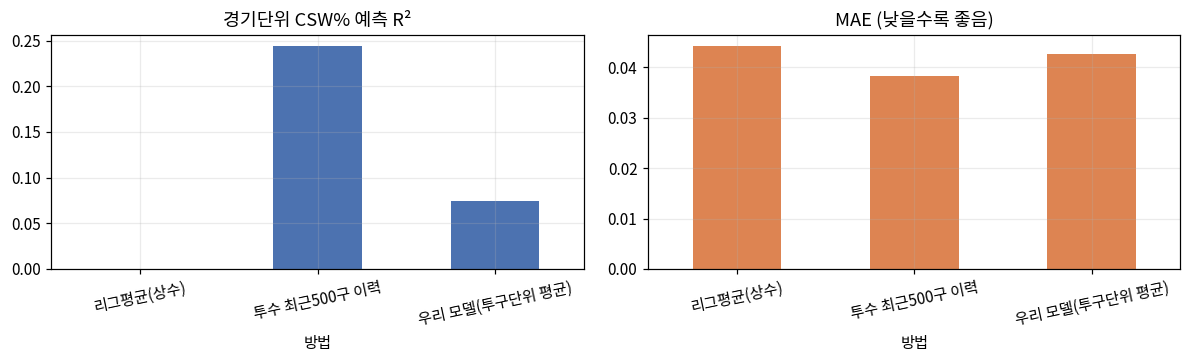

,MAE,RMSE,R2,상관
방법,,,,
리그평균(상수),0.0443,0.0555,-0.0000,NaN
투수 최근500구 이력,0.0383,0.0483,0.2443,0.4975
우리 모델(투구단위 평균),0.0426,0.0534,0.0746,0.3945


In [6]:
R = json.load(open(V3.parent/"v2"/"rate_diagnosis.json"))
r = pd.DataFrame(R["results"]).set_index("방법")
print(f"등판 {R['n_outings']}개 | 실제 CSW% SD {R['actual_sd']:.4f}")
fig, ax = plt.subplots(1,2, figsize=(11,3.4))
r["R2"].plot.bar(ax=ax[0], color="#4C72B0"); ax[0].set_title("경기단위 CSW% 예측 R²"); plt.setp(ax[0].get_xticklabels(), rotation=12)
r["MAE"].plot.bar(ax=ax[1], color="#DD8452"); ax[1].set_title("MAE (낮을수록 좋음)"); plt.setp(ax[1].get_xticklabels(), rotation=12)
plt.tight_layout(); plt.show()
r

## 6. EDA 결론 → 방향 조정
1. **CSW는 두 사건의 합** → 분리 모델링 시도 (**F**)
2. **카운트가 지배적**, 나머지 피처의 한계 효용이 작다 → 피처를 늘리기보다 **구조**를 바꿔야 함
3. **천장이 낮다**: 위치를 모르는 한 AUC 0.63 부근이 현실적 상한
4. **비율 예측은 이동평균이 우세** → 투구 단위 평균은 비율 예측에 부적합
→ 다음: **E** 피처 확장(Pitch Predict 차용)+고강도 튜닝, **F** CS/W 분해